In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## ResNet-UNet Architecture
U-Net with a ResNet encoder (ImageNet-pretrained by default) and a U-Net decoder with transposed-conv upsampling, skip connections and dropout.

In [2]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_rate=0.15, use_dropout=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if use_dropout:
            layers.append(nn.Dropout2d(dropout_rate))

        layers.extend([
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ])
        if use_dropout:
            layers.append(nn.Dropout2d(dropout_rate))

        self.double_conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.double_conv(x)

# (constructor, ImageNet weights enum name, channels of [stem, layer1, layer2, layer3, layer4])
RESNET_CFG = {
    'resnet18':  (models.resnet18,  'ResNet18_Weights',  [64, 64, 128, 256, 512]),
    'resnet34':  (models.resnet34,  'ResNet34_Weights',  [64, 64, 128, 256, 512]),
    'resnet50':  (models.resnet50,  'ResNet50_Weights',  [64, 256, 512, 1024, 2048]),
    'resnet101': (models.resnet101, 'ResNet101_Weights', [64, 256, 512, 1024, 2048]),
}

class ResNetUNet(nn.Module):
    """U-Net with a ResNet encoder.

    Encoder (strides relative to the input):
        stem   (conv7x7 + BN + ReLU)  /2
        layer1 (after maxpool)        /4
        layer2                        /8
        layer3                        /16
        layer4 (bottleneck)           /32
    Decoder: ConvTranspose2d x2 + skip concat + DoubleConv, five times, back to full resolution.
    Input height/width must be divisible by 32 (256x256 is fine).
    """
    def __init__(self, backbone='resnet34', pretrained=True, in_ch=3, out_ch=1,
                 dropout_rates=None):
        super().__init__()
        if backbone not in RESNET_CFG:
            raise ValueError(f"backbone must be one of {list(RESNET_CFG)}")

        if dropout_rates is None:
            dropout_rates = {
                'encoder': {'layer3': 0.15, 'layer4': 0.2},   # same idea as U-Net: enc4 = 0.15, bottleneck = 0.2
                'decoder': 0.15,
            }
        self.dropout_rates = dropout_rates

        ctor, weights_name, ch = RESNET_CFG[backbone]
        weights = getattr(models, weights_name).IMAGENET1K_V1 if pretrained else None
        backbone_net = ctor(weights=weights)

        # Optional: support in_ch != 3 by rebuilding the first conv
        if in_ch != 3:
            backbone_net.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Encoder
        self.stem = nn.Sequential(backbone_net.conv1, backbone_net.bn1, backbone_net.relu)  # /2
        self.pool = backbone_net.maxpool                                                    # /4
        self.layer1 = backbone_net.layer1
        self.layer2 = backbone_net.layer2
        self.layer3 = backbone_net.layer3
        self.layer4 = backbone_net.layer4

        self.drop3 = nn.Dropout2d(dropout_rates['encoder']['layer3'])
        self.drop4 = nn.Dropout2d(dropout_rates['encoder']['layer4'])

        c0, c1, c2, c3, c4 = ch
        d = dropout_rates['decoder']

        # Decoder
        self.up4 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)       # /32 -> /16
        self.dec4 = DoubleConv(c3 * 2, c3, d, use_dropout=True)
        self.up3 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)       # /16 -> /8
        self.dec3 = DoubleConv(c2 * 2, c2, d, use_dropout=True)
        self.up2 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)       # /8  -> /4
        self.dec2 = DoubleConv(c1 * 2, c1, d, use_dropout=True)
        self.up1 = nn.ConvTranspose2d(c1, c0, kernel_size=2, stride=2)       # /4  -> /2
        self.dec1 = DoubleConv(c0 * 2, c0, d, use_dropout=True)
        self.up0 = nn.ConvTranspose2d(c0, 32, kernel_size=2, stride=2)       # /2  -> full res
        self.dec0 = DoubleConv(32, 32, d, use_dropout=True)

        self.final_conv = nn.Conv2d(32, out_ch, kernel_size=1)

    def forward(self, x):
        # Encoder
        e0 = self.stem(x)                       # /2
        e1 = self.layer1(self.pool(e0))         # /4
        e2 = self.layer2(e1)                    # /8
        e3 = self.drop3(self.layer3(e2))        # /16
        b = self.drop4(self.layer4(e3))         # /32 (bottleneck)

        # Decoder
        d4 = self.dec4(torch.cat([self.up4(b), e3], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e2], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e1], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e0], dim=1))
        d0 = self.dec0(self.up0(d1))

        return self.final_conv(d0)


## Dataset and Data Loading

In [3]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

class SegDataset(Dataset):
    """Reads from a pre-made split folder that already contains 'img/' and 'mask/'
    subfolders (e.g. root_dir/train/Img, root_dir/train/Masks). Mask files are named
    '<stem>_mask.<ext>' (folder-name case is ignored)."""
    def __init__(self, root_dir, split='train', transform=None, img_size=(256, 256)):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.transform = transform

        split_dir = os.path.join(root_dir, split)
        # case-insensitive lookup so 'Img' / 'img' and 'Masks' / 'masks' all work
        def _sub(name):
            for d in os.listdir(split_dir):
                if d.lower() == name:
                    return os.path.join(split_dir, d)
            raise FileNotFoundError(f"'{name}' folder not found in {split_dir}: {os.listdir(split_dir)}")
        self.img_dir = _sub('img')
        self.mask_dir = _sub('masks')

        mask_stems = {os.path.splitext(f)[0].replace('_mask', ''): f
                      for f in os.listdir(self.mask_dir) if f.lower().endswith(IMG_EXTS)}

        self.pairs = []
        for f in sorted(os.listdir(self.img_dir)):
            if not f.lower().endswith(IMG_EXTS):
                continue
            stem = os.path.splitext(f)[0]
            if stem in mask_stems:
                self.pairs.append((f, mask_stems[stem]))

        assert len(self.pairs) > 0, f"No image/mask pairs found under {split_dir}"

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.pairs[idx]

        img = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')
        label = Image.open(os.path.join(self.mask_dir, mask_name)).convert('L')

        img = img.resize(self.img_size)
        label = label.resize(self.img_size, Image.NEAREST)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = torch.from_numpy((np.array(label) > 0).astype(np.float32)).unsqueeze(0)

        return img, label


## Loss Functions and Metrics

In [4]:
def dice_coef(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    denom = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        dice = dice_coef(pred, target, smooth=self.smooth)
        return 1.0 - dice

def combined_loss(logits, mask, bce_weight=0.6, dice_weight=0.4):
    bce_loss = nn.BCEWithLogitsLoss()
    bce = bce_loss(logits, mask)
    probs = torch.sigmoid(logits)
    dice = DiceLoss()(probs, mask)
    return bce_weight * bce + dice_weight * dice

@torch.no_grad()
def compute_metrics_batch(logits, masks, thresh=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thresh).float()
    preds_flat = preds.view(-1).cpu().numpy()
    masks_flat = masks.view(-1).cpu().numpy()
    
    unique_preds = np.unique(preds_flat)
    unique_masks = np.unique(masks_flat)
    
    if len(unique_preds) == 1 and len(unique_masks) == 1:
        if unique_preds[0] == unique_masks[0]:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = len(preds_flat), 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, len(preds_flat)
        else:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = 0, len(preds_flat), 0, 0
            else:
                tp, fp, fn, tn = 0, 0, len(preds_flat), 0
    else:
        cm = confusion_matrix(masks_flat, preds_flat, labels=[0,1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            if cm.shape == (1, 1):
                if unique_masks[0] == 0:
                    tn, fp, fn, tp = cm[0,0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0,0]
            else:
                tn, fp, fn, tp = 0, 0, 0, 0
    
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "iou": float(iou), "dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "acc": float(acc), "miou": float(miou)}

## Training and Validation Functions

In [5]:
import copy

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = copy.deepcopy(model.state_dict())

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Train batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    train_acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, train_acc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Val batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    epoch_loss = running_loss / len(loader.dataset)
    metrics = {"loss": epoch_loss, "iou": iou, "dice": dice, "precision": precision,
               "recall": recall, "f1": f1, "acc": acc, "miou": miou,
               "confusion": np.array([[tn, fp], [fn, tp]])}
    return metrics

def train_model(model, train_loader, val_loader, num_epochs=200, learning_rate=2e-4, patience=10):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = optim.AdamW(
        [
            {"params": decay, "weight_decay": 1e-2},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, min_lr=1e-6
    )
    
    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4)
    
    train_losses = []
    val_losses = []
    val_ious = []
    val_dices = []
    train_accs = []
    val_accs = []
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        
        val_metrics = validate(model, val_loader)
        
        scheduler.step(val_metrics['loss'])
        
        print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.6f} | Val Acc: {val_metrics['acc']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        
        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
        val_ious.append(val_metrics['iou'])
        val_dices.append(val_metrics['dice'])
        train_accs.append(train_acc)
        val_accs.append(val_metrics['acc'])
        
        if val_metrics['loss'] < best_val_loss - 1e-4:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'BSP_ResNetUNet.pth')
            print(f"Saved best model with validation loss: {best_val_loss:.6f}")
        
        if early_stopping(val_metrics['loss'], model):
            print(f'Early stopping triggered after {epoch+1} epochs')
            break
    
    return train_losses, val_losses, val_ious, val_dices, train_accs, val_accs

## Training Configuration and Execution


In [6]:
def main():
    # Hyperparameters
    BATCH_SIZE = 5
    LEARNING_RATE = 2e-4
    NUM_EPOCHS = 30
    PATIENCE = 3
    IMG_SIZE = (256, 256)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # folder that contains train/, val/, test/ — each with its own img/ and mask/ subfolders
    # (use 'train_augmented' if that's what you uploaded as your train split)
    root_dir = "/kaggle/input/datasets/chinnuuuuu/bangaloresolarpanels-augmented/BangaloreSolarPanels_augmented"
    
    train_dataset = SegDataset(root_dir, split='train', transform=transform, img_size=IMG_SIZE)
    val_dataset = SegDataset(root_dir, split='val', transform=transform, img_size=IMG_SIZE)
    test_dataset = SegDataset(root_dir, split='test', transform=transform, img_size=IMG_SIZE)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    # ResNet encoder (set PRETRAINED=False to train the encoder from scratch)
    BACKBONE = 'resnet34'      # 'resnet18' | 'resnet34' | 'resnet50' | 'resnet101'
    PRETRAINED = True
    # dropout as U-Net: encoder layer3 = 0.15, bottleneck (layer4) = 0.2, decoder = 0.15
    dropout_config = {
        'encoder': {'layer3': 0.15, 'layer4': 0.2},
        'decoder': 0.15,
    }
    
    model = ResNetUNet(backbone=BACKBONE, pretrained=PRETRAINED, in_ch=3, out_ch=1,
                       dropout_rates=dropout_config).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    print(f"\nStarting ResNet-UNet training ({BACKBONE}, pretrained={PRETRAINED})")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Weight Decay: 1e-3")
    print(f"Dropout: {dropout_config}")
    print(f"Threshold: 0.5")
    print(f"Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)\n")
    
    train_losses, val_losses, val_ious, val_dices, train_accs, val_accs = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE
    )
    
    return model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader

model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader = main()

Training samples: 160
Validation samples: 10
Test samples: 13
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 248MB/s]


Total parameters: 24,451,585

Starting ResNet-UNet training (resnet34, pretrained=True)
Learning Rate: 0.0002
Weight Decay: 1e-3
Dropout: {'encoder': {'layer3': 0.15, 'layer4': 0.2}, 'decoder': 0.15}
Threshold: 0.5
Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)


Epoch 1/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 25.43it/s]


Train Loss: 0.775589 | Train Acc: 0.6559
Val Loss: 0.728776 | Val Acc: 0.9595 | IoU: 0.4952 | Dice: 0.6624 | F1: 0.6624
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.728776

Epoch 2/30


...

Train Loss: 0.268412 | Train Acc: 0.9983
Val Loss: 0.244735 | Val Acc: 0.9908 | IoU: 0.8088 | Dice: 0.8943 | F1: 0.8943
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.244735

Epoch 29/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 42.68it/s]


Train Loss: 0.262446 | Train Acc: 0.9984
Val Loss: 0.224753 | Val Acc: 0.9914 | IoU: 0.8228 | Dice: 0.9028 | F1: 0.9028
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.224753

Epoch 30/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 41.55it/s]

Train Loss: 0.251103 | Train Acc: 0.9983
Val Loss: 0.229032 | Val Acc: 0.9913 | IoU: 0.8139 | Dice: 0.8974 | F1: 0.8974
Learning Rate: 2.00e-04


## Visualization of Training Progress

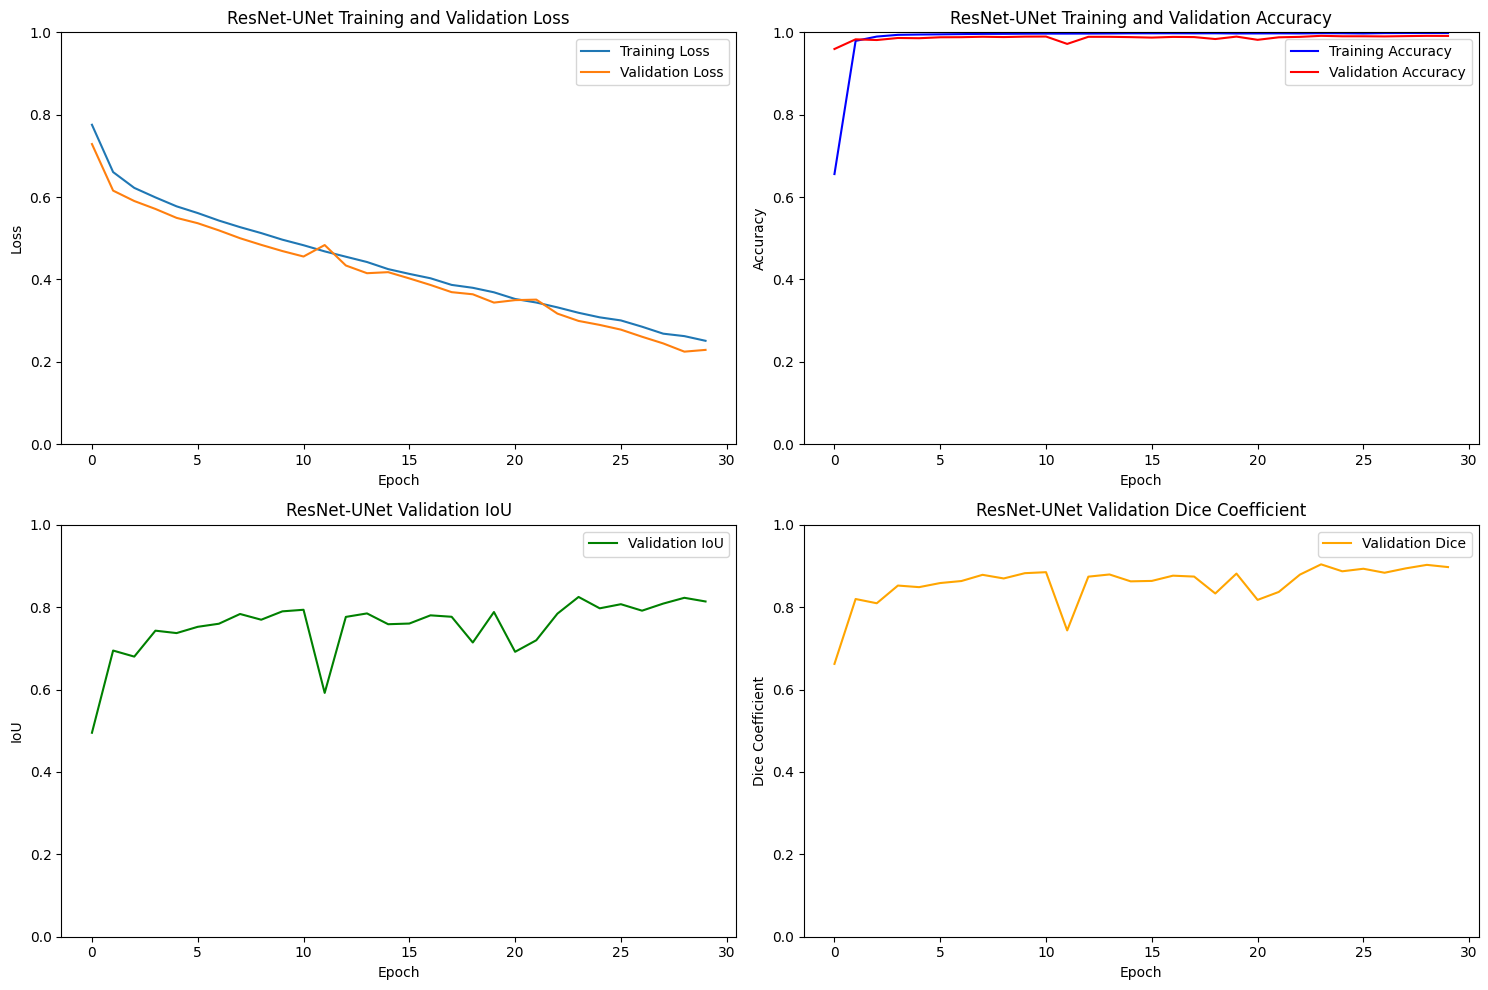

In [7]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.set_title('ResNet-UNet Training and Validation Loss')

ax2.plot(train_accs, label='Training Accuracy', color='blue')
ax2.plot(val_accs, label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.set_title('ResNet-UNet Training and Validation Accuracy')

ax3.plot(val_ious, label='Validation IoU', color='green')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('IoU')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.set_title('ResNet-UNet Validation IoU')

ax4.plot(val_dices, label='Validation Dice', color='orange')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Dice Coefficient')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.set_title('ResNet-UNet Validation Dice Coefficient')

plt.tight_layout()
plt.savefig('BSP_ResNetUNet_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Test Evaluation

Loading best ResNet-UNet model for test evaluation...

Evaluating ResNet-UNet on test set...


Val batch: 100%|██████████| 13/13 [00:00<00:00, 38.35it/s]



TEST EVALUATION METRICS
Configuration: ResNet-UNet | dropout as U-Net: layer3 = 0.15, bottleneck = 0.2, decoder = 0.15
Test set processed with batch_size=1
Loss:            0.212752
IoU:             0.8890
mIoU:            0.9417
Dice Coefficient: 0.9412
Accuracy:        0.9947
Precision:       0.9126
Recall:          0.9717
F1-Score:        0.9412
Confusion matrix (pixel-level):
[[811164   3476]
 [  1055  36273]]


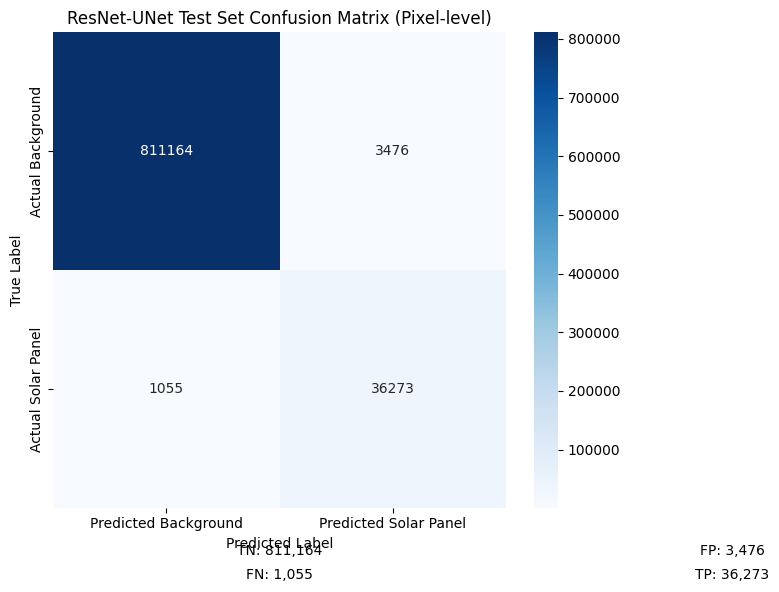

ResNet-UNet training and evaluation completed!


In [8]:
print("Loading best ResNet-UNet model for test evaluation...")
model.load_state_dict(torch.load('BSP_ResNetUNet.pth', map_location=device))
model.to(device)

print("\nEvaluating ResNet-UNet on test set...")
test_metrics = validate(model, test_loader)

print("\n" + "="*50)
print("TEST EVALUATION METRICS")
print("Configuration: ResNet-UNet | dropout as U-Net: layer3 = 0.15, bottleneck = 0.2, decoder = 0.15")
print("="*50)
print(f"Test set processed with batch_size=1")
print(f"Loss:            {test_metrics['loss']:.6f}")
print(f"IoU:             {test_metrics['iou']:.4f}")
print(f"mIoU:            {test_metrics['miou']:.4f}")
print(f"Dice Coefficient: {test_metrics['dice']:.4f}")
print(f"Accuracy:        {test_metrics['acc']:.4f}")
print(f"Precision:       {test_metrics['precision']:.4f}")
print(f"Recall:          {test_metrics['recall']:.4f}")
print(f"F1-Score:        {test_metrics['f1']:.4f}")
print("Confusion matrix (pixel-level):")
print(test_metrics["confusion"])
print("="*50)

plt.figure(figsize=(8, 6))
cm = test_metrics["confusion"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Background', 'Predicted Solar Panel'],
            yticklabels=['Actual Background', 'Actual Solar Panel'])
plt.title('ResNet-UNet Test Set Confusion Matrix (Pixel-level)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.text(0.5, -0.1, f'TN: {cm[0,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.1, f'FP: {cm[0,1]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(0.5, -0.15, f'FN: {cm[1,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.15, f'TP: {cm[1,1]:,}', ha='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('BSP_ResNetUNet_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("ResNet-UNet training and evaluation completed!")


## Test the model on images

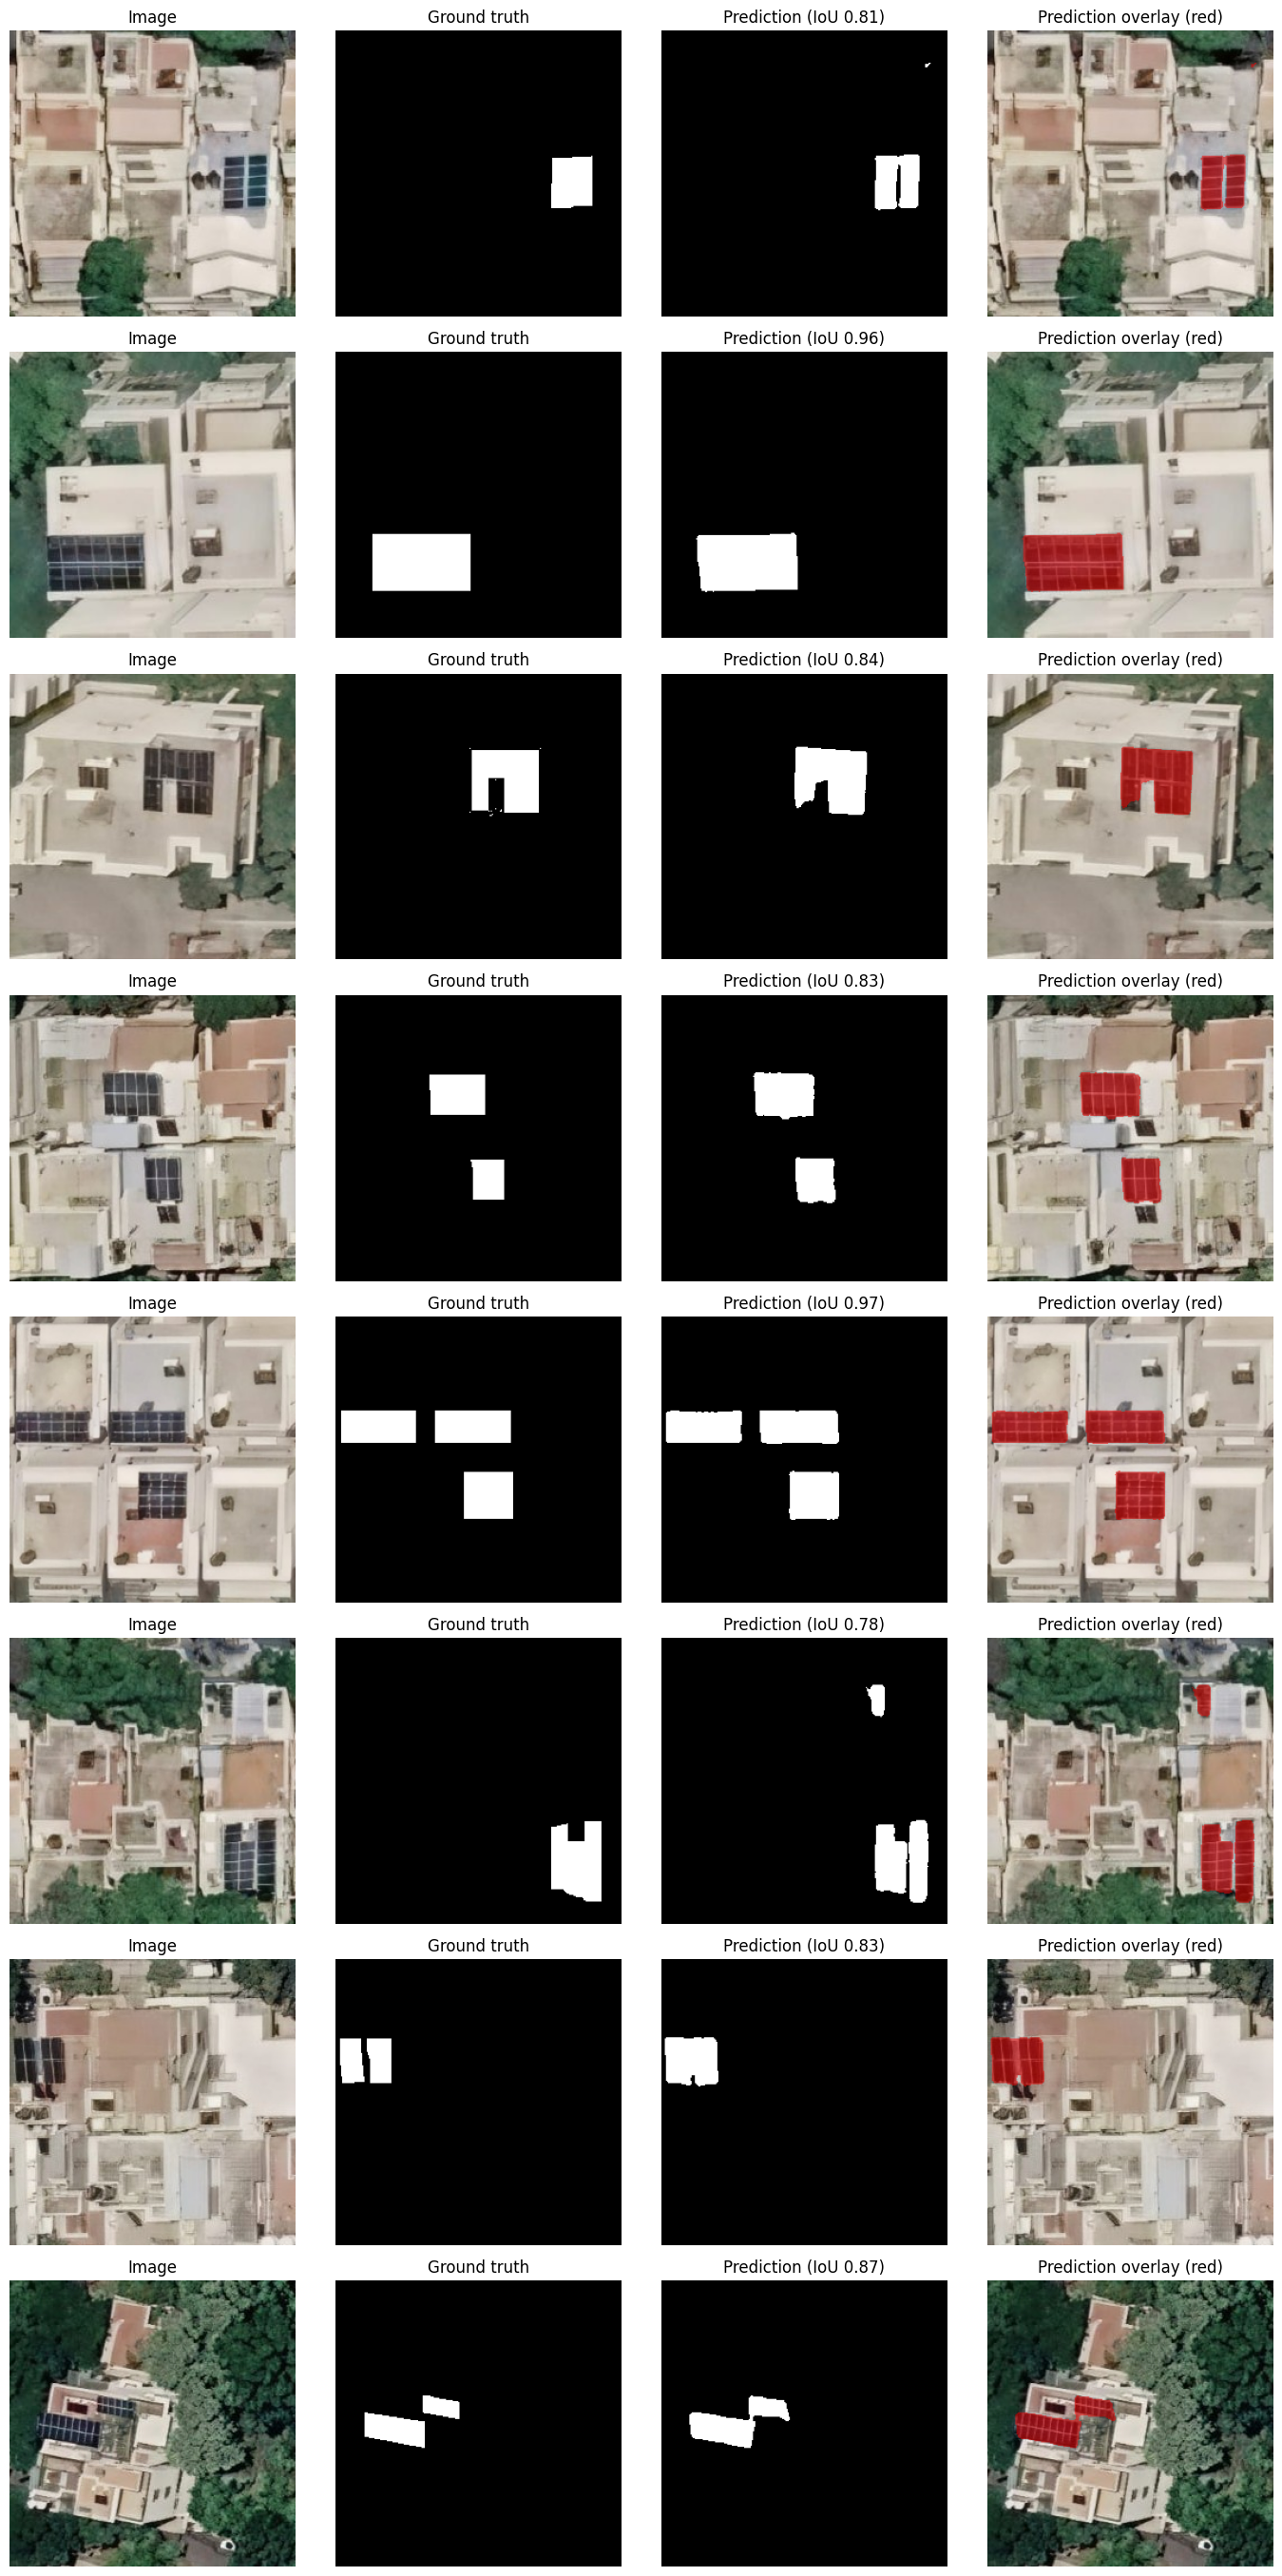

In [9]:
import random

root_dir = '/kaggle/input/datasets/chinnuuuuu/bangaloresolarpanels-augmented/BangaloreSolarPanels_augmented'
IMG_SIZE = (256, 256)
BACKBONE = 'resnet34'   # must match the backbone used in training
DROPOUT = {'encoder': {'layer3': 0.15, 'layer4': 0.2}, 'decoder': 0.15}
CKPT = 'BSP_ResNetUNet.pth'

# rebuild the test set and load the best checkpoint
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_ds = SegDataset(root_dir, split='test', transform=tf, img_size=IMG_SIZE)

net = ResNetUNet(backbone=BACKBONE, pretrained=False, in_ch=3, out_ch=1, dropout_rates=DROPOUT).to(device)
net.load_state_dict(torch.load(CKPT, map_location=device))
net.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_predictions(n=8, seed=0, thresh=0.5):
    random.seed(seed)
    idxs = random.sample(range(len(test_ds)), n)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    for r, i in enumerate(idxs):
        img, gt = test_ds[i]
        with torch.no_grad():
            prob = torch.sigmoid(net(img.unsqueeze(0).to(device)))[0, 0].cpu()
        pred = (prob >= thresh).float()

        rgb = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        gt_np, pred_np = gt[0].numpy(), pred.numpy()

        inter = (gt_np * pred_np).sum()
        union = gt_np.sum() + pred_np.sum() - inter
        iou = inter / union if union > 0 else float('nan')

        overlay = rgb.copy()
        overlay[pred_np > 0] = 0.5 * overlay[pred_np > 0] + 0.5 * np.array([1, 0, 0])

        axes[r, 0].imshow(rgb);                  axes[r, 0].set_title("Image")
        axes[r, 1].imshow(gt_np, cmap='gray');   axes[r, 1].set_title("Ground truth")
        axes[r, 2].imshow(pred_np, cmap='gray'); axes[r, 2].set_title(f"Prediction (IoU {iou:.2f})")
        axes[r, 3].imshow(overlay);              axes[r, 3].set_title("Prediction overlay (red)")
        for a in axes[r]: a.axis('off')
    plt.tight_layout()
    plt.savefig('BSP_ResNetUNet_predictions.png', dpi=200, bbox_inches='tight')
    plt.show()

show_predictions(n=8, seed=0)
